In [2]:
import h5py
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.preprocessing.text import Tokenizer
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, SpatialDropout1D
from sklearn.model_selection import train_test_split

Using TensorFlow backend.
/home/quarantine/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/quarantine/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/quarantine/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/quarantine/.local/lib/python3.6/site-packages/t

In [3]:
table = pd.read_csv('data/data.csv')
table["title+body"] = table['title'].fillna(' ')+table['body'].fillna(' ')

#table['title_and_body'] = table['title']+table['body']
#table = table[['title', 'flair']]

#print(table)
labels = ['Politics','[R]eddiquette','Non-Political','AskIndia','Policy/Economy','Business/Finance','Science/Technology','Sports','Photography','AMA']
table = table[table.flair.isin(labels)]

In [4]:
table.head()

,Unnamed: 0,title,body,flair,score,number of comments,title+body
0,334,How to transport a bed for free in Bangalore?,NaN,Non-Political,1856,179,How to transport a bed for free in Bangalore?
1,670,[OC] Delhi Metro gets a Google Assistant Actio...,NaN,Science/Technology,1303,85,[OC] Delhi Metro gets a Google Assistant Actio...
2,142,"""I bless the rains down in Africa""",NaN,Non-Political,2746,131,"""I bless the rains down in Africa"""
3,137,When you're promoting a patriotic movie but so...,NaN,Non-Political,2779,395,When you're promoting a patriotic movie but so...
4,385,"Yin and yang puppies on the road, should i tak...",NaN,AskIndia,1763,214,"Yin and yang puppies on the road, should i tak..."


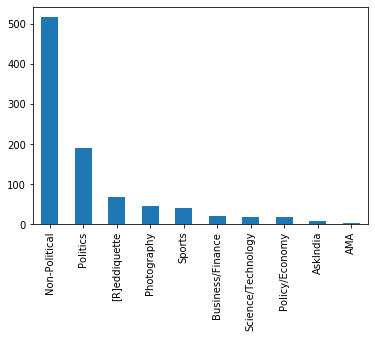

In [5]:
table.flair.value_counts().plot(kind='bar')

In [6]:
table.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 929 entries, 0 to 989
Data columns (total 7 columns):
Unnamed: 0            929 non-null int64
title                 929 non-null object
body                  69 non-null object
flair                 929 non-null object
score                 929 non-null int64
number of comments    929 non-null int64
title+body            929 non-null object
dtypes: int64(3), object(4)
memory usage: 58.1+ KB


In [7]:
print(table.flair.value_counts())
print(table.flair.unique())

Non-Political         517
Politics              191
[R]eddiquette          67
Photography            46
Sports                 40
Business/Finance       21
Science/Technology     19
Policy/Economy         18
AskIndia                8
AMA                     2
Name: flair, dtype: int64
['Non-Political' 'Science/Technology' 'AskIndia' 'Photography' 'Politics'
 '[R]eddiquette' 'Business/Finance' 'Sports' 'Policy/Economy' 'AMA']


In [8]:
def print_plot(index):
    example = table[table.index == index][['title+body', 'flair']].values[0]
    return example[0], example[1]
#    if len(example) > 0:
#         print(example[0])
#         print('flair: ', example[1])
#         return example[0], example[1]
        

In [9]:
def values(index):
    return table['title+body'][index], table['flair'][index]

In [10]:
table_list = []
for i in table.index:
    title_body, flair = print_plot(i)
    flag = {
        "title+body": title_body,
        "flair": flair
    }
    table_list.append(flag)

In [11]:
table_list

[{'title+body': 'How to transport a bed for free in Bangalore? ',
  'flair': 'Non-Political'},
 {'title+body': '[OC] Delhi Metro gets a Google Assistant Action! (Say "Talk To Delhi Metro" to try it out). ',
  'flair': 'Science/Technology'},
 {'title+body': '"I bless the rains down in Africa" ',
  'flair': 'Non-Political'},
 {'title+body': "When you're promoting a patriotic movie but someone asks to show your passport ",
  'flair': 'Non-Political'},
 {'title+body': 'Yin and yang puppies on the road, should i take them? ',
  'flair': 'AskIndia'},
 {'title+body': 'My Father sent me this photo last year while traveling around India. ',
  'flair': 'Photography'},
 {'title+body': "Announcement. This house has been looted thrice already, hence all money, gold, etc are stored in bank. Don't break the lock in futility. ",
  'flair': 'Non-Political'},
 {'title+body': 'BEWARE: while using Jio Public Wi-Fi, you are agreeing to these iniquitous terms. This is unacceptable. ',
  'flair': 'Non-Politi

In [12]:
import pymongo

In [13]:
client = pymongo.MongoClient('mongodb://localhost:27017/')
instance = client['DataBase']
final = instance['site']

In [14]:
x = final.collection.insert(table_list)

/home/quarantine/.local/lib/python3.6/site-packages/ipykernel_launcher.py:1: DeprecationWarning: insert is deprecated. Use insert_one or insert_many instead.
  """Entry point for launching an IPython kernel.


In [15]:
x

[ObjectId('5d74e0dfd626a553e3786730'),
 ObjectId('5d74e0dfd626a553e3786731'),
 ObjectId('5d74e0dfd626a553e3786732'),
 ObjectId('5d74e0dfd626a553e3786733'),
 ObjectId('5d74e0dfd626a553e3786734'),
 ObjectId('5d74e0dfd626a553e3786735'),
 ObjectId('5d74e0dfd626a553e3786736'),
 ObjectId('5d74e0dfd626a553e3786737'),
 ObjectId('5d74e0dfd626a553e3786738'),
 ObjectId('5d74e0dfd626a553e3786739'),
 ObjectId('5d74e0dfd626a553e378673a'),
 ObjectId('5d74e0dfd626a553e378673b'),
 ObjectId('5d74e0dfd626a553e378673c'),
 ObjectId('5d74e0dfd626a553e378673d'),
 ObjectId('5d74e0dfd626a553e378673e'),
 ObjectId('5d74e0dfd626a553e378673f'),
 ObjectId('5d74e0dfd626a553e3786740'),
 ObjectId('5d74e0dfd626a553e3786741'),
 ObjectId('5d74e0dfd626a553e3786742'),
 ObjectId('5d74e0dfd626a553e3786743'),
 ObjectId('5d74e0dfd626a553e3786744'),
 ObjectId('5d74e0dfd626a553e3786745'),
 ObjectId('5d74e0dfd626a553e3786746'),
 ObjectId('5d74e0dfd626a553e3786747'),
 ObjectId('5d74e0dfd626a553e3786748'),
 ObjectId('5d74e0dfd626a5

In [16]:
print_plot(1)

('[OC] Delhi Metro gets a Google Assistant Action! (Say "Talk To Delhi Metro" to try it out). ',
 'Science/Technology')

In [17]:
import re
from nltk.corpus import stopwords
table = table.reset_index(drop=True)
REPLACE_BY_SPACE_RE = re.compile('[/(){}\[\]\|@,;]')
BAD_SYMBOLS_RE = re.compile('[^0-9a-z #+_]')
STOPWORDS = set(stopwords.words('english'))

In [18]:
def clean_text(text):
    text = text.lower() # lowercase text
    text = REPLACE_BY_SPACE_RE.sub(' ', text) # replace REPLACE_BY_SPACE_RE symbols by space in text. substitute the matched string in REPLACE_BY_SPACE_RE with space.
    text = BAD_SYMBOLS_RE.sub('', text) # remove symbols which are in BAD_SYMBOLS_RE from text. substitute the matched string in BAD_SYMBOLS_RE with nothing. 
    text = text.replace('x', '') # text = re.sub(r'\W+', '', text)
    text = ' '.join(word for word in text.split() if word not in STOPWORDS) # remove stopwors from text
    return text

In [19]:
table['title'] = table['title'].str.replace('\d+', '')

In [20]:
max_words = 50000
max_sequence_len = 250
embedding = 100
filters = '!"#$%&()*+,-./:;<=>?@[\]^_`{|}~'

tokenizer = Tokenizer(num_words=max_words, filters=filters, lower=True)
tokenizer.fit_on_texts(table['title'].values)
word_index = tokenizer.word_index
print(word_index)
print('Found %s unique tokens.' % len(word_index))

{'the': 1, 'in': 2, 'a': 3, 'of': 4, 'to': 5, 'and': 6, 'this': 7, 'i': 8, 'india': 9, 'on': 10, 'is': 11, 'my': 12, 'for': 13, 'from': 14, 'you': 15, 'at': 16, 'it': 17, 'indian': 18, 'with': 19, 'by': 20, 'np': 21, 'was': 22, 'are': 23, 'his': 24, 'be': 25, 'mumbai': 26, 'who': 27, 'x': 28, 'first': 29, 'me': 30, 'r': 31, 'your': 32, 'when': 33, 'as': 34, 'up': 35, 'not': 36, 'that': 37, 'have': 38, 'an': 39, 'one': 40, 'like': 41, 'after': 42, 'people': 43, 'no': 44, 'just': 45, 'delhi': 46, 'has': 47, 'our': 48, 'how': 49, 'made': 50, 'day': 51, 'he': 52, 'oc': 53, 'all': 54, 'kerala': 55, 'today': 56, 'two': 57, 'world': 58, 'found': 59, 'but': 60, 'them': 61, 'year': 62, "don't": 63, 'post': 64, 'hyderabad': 65, 'we': 66, 'her': 67, 'new': 68, 'time': 69, 'should': 70, 'so': 71, 'old': 72, 'here': 73, 'about': 74, 'these': 75, 'modi': 76, 'their': 77, 'last': 78, 'if': 79, 'what': 80, 'been': 81, 'took': 82, 'get': 83, 'years': 84, 'can': 85, 'life': 86, 'morning': 87, 'got': 88,

In [21]:
from keras.preprocessing.sequence import pad_sequences
X = tokenizer.texts_to_sequences(table['title+body'].values)
X = pad_sequences(X, maxlen=max_sequence_len)
print('Shape of data tensor:', X.shape)

Shape of data tensor: (929, 250)


In [22]:
Y = pd.get_dummies(table['flair']).values
print('Shape of label tensor:', Y.shape)
table.flair.unique()

Shape of label tensor: (929, 10)


array(['Non-Political', 'Science/Technology', 'AskIndia', 'Photography',
       'Politics', '[R]eddiquette', 'Business/Finance', 'Sports',
       'Policy/Economy', 'AMA'], dtype=object)

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.10, random_state = 42)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(836, 250) (836, 10)
(93, 250) (93, 10)


In [30]:
model = Sequential()
#model.load('model.h5')
model.add(Embedding(max_words, embedding, input_length=X.shape[1]))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(64, activation='relu'))
#model.add(LSTM(64, dropout=0.15, recurrent_dropout=0.15))
model.add(Dense(10, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_2 (Embedding)      (None, 250, 100)          5000000   
_________________________________________________________________
spatial_dropout1d_2 (Spatial (None, 250, 100)          0         
_________________________________________________________________
lstm_2 (LSTM)                (None, 128)               117248    
_________________________________________________________________
dense_3 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_4 (Dense)              (None, 10)                650       
Total params: 5,126,154
Trainable params: 5,126,154
Non-trainable params: 0
_________________________________________________________________
None


In [35]:
from keras.callbacks import EarlyStopping
epochs = 50
batch_size = 64

history = model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.1,callbacks=[EarlyStopping(monitor='val_loss', patience=3, min_delta=0.0001)])
model.save('model.h5')

Train on 752 samples, validate on 84 samples
Epoch 1/50
752/752 [==============================] - 7s 9ms/step - loss: 0.7027 - acc: 0.7606 - val_loss: 1.8082 - val_acc: 0.5000
Epoch 2/50
752/752 [==============================] - 5s 6ms/step - loss: 0.6104 - acc: 0.8019 - val_loss: 1.9587 - val_acc: 0.4762
Epoch 3/50
752/752 [==============================] - 5s 6ms/step - loss: 0.5248 - acc: 0.8258 - val_loss: 2.2253 - val_acc: 0.4405
Epoch 4/50
752/752 [==============================] - 5s 6ms/step - loss: 0.4486 - acc: 0.8590 - val_loss: 2.2166 - val_acc: 0.5000


In [36]:
accr = model.evaluate(X_test,Y_test)
print('Test set\n  Loss: {:0.3f}\n  Accuracy: {:0.3f}'.format(accr[0],accr[1]))

93/93 [==============================] - 0s 3ms/step
Test set
  Loss: 2.427
  Accuracy: 0.430


In [37]:
from keras.models import model_from_json
from keras.models import load_model

model_json = model.to_json()

with open("model_num.json", "w") as json_file:
    json_file.write(model_json)
    
model.save_weights("model_num.hdf5")


In [27]:
# from keras.models import load_model
# model = load_model('model.h5')
# model

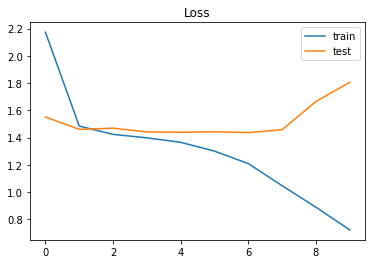

In [26]:
plt.title('Loss')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

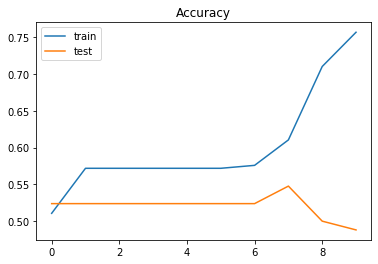

In [27]:
plt.title('Accuracy')
plt.plot(history.history['acc'], label='train')
plt.plot(history.history['val_acc'], label='test')
plt.legend()
plt.show();

In [32]:
post_text = input("enter post text: ")
seq = tokenizer.texts_to_sequences(post_text)
padded = pad_sequences(seq, maxlen=max_sequence_len)
pred = model.predict(padded)
pred = np.mean(pred, axis=0)
labels = ['Politics','[R]eddiquette','Non-Political','AskIndia','Policy/Economy','Business/Finance','Science/Technology','Sports','Photography','AMA']
print(pred, labels[np.argmax(pred)])

enter post text: i am scared of my life lemme rest in peace
[1.1378653e-04 9.0770511e-04 3.4301681e-03 4.8933211e-01 1.5423634e-02
 2.6882435e-03 4.3067956e-01 1.9678797e-03 1.3177751e-02 4.2278867e-02] AskIndia
